In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
os.chdir("/home/david/technocolabs/EDA/data/") 

In [3]:
df = pd.read_csv('LoanExport.csv', low_memory=False)
df.head()

,CreditScore,FirstPaymentDate,FirstTimeHomebuyer,MaturityDate,MSA,MIP,Units,Occupancy,OCLTV,DTI,...,PostalCode,LoanSeqNum,LoanPurpose,OrigLoanTerm,NumBorrowers,SellerName,ServicerName,EverDelinquent,MonthsDelinquent,MonthsInRepayment
0,0,199902,N,202901,16974,25,1,O,89,27,...,60400,F199Q1268030,P,360,2,FL,WASHINGTONMUTUALBANK,0,0,52
1,0,199902,N,202901,19740,0,1,O,73,17,...,80200,F199Q1015092,N,360,1,FT,CHASEHOMEFINANCELLC,0,0,144
2,0,199902,N,202901,29940,0,1,O,75,16,...,66000,F199Q1266886,N,360,2,FL,WASHINGTONMUTUALBANK,0,0,67
3,0,199902,N,202901,31084,0,1,O,76,14,...,90700,F199Q1178167,N,360,2,GM,GMACMTGECORP,0,0,35
4,0,199902,N,202901,35644,0,1,O,78,18,...,7600,F199Q1178517,N,360,2,GM,GMACMTGECORP,0,0,54


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291451 entries, 0 to 291450
Data columns (total 28 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   CreditScore         291451 non-null  int64  
 1   FirstPaymentDate    291451 non-null  int64  
 2   FirstTimeHomebuyer  291451 non-null  object 
 3   MaturityDate        291451 non-null  int64  
 4   MSA                 291451 non-null  object 
 5   MIP                 291451 non-null  int64  
 6   Units               291451 non-null  int64  
 7   Occupancy           291451 non-null  object 
 8   OCLTV               291451 non-null  int64  
 9   DTI                 291451 non-null  int64  
 10  OrigUPB             291451 non-null  int64  
 11  LTV                 291451 non-null  int64  
 12  OrigInterestRate    291451 non-null  float64
 13  Channel             291451 non-null  object 
 14  PPM                 291451 non-null  object 
 15  ProductType         291451 non-nul

In [5]:
df.isnull().sum()

CreditScore               0
FirstPaymentDate          0
FirstTimeHomebuyer        0
MaturityDate              0
MSA                       0
MIP                       0
Units                     0
Occupancy                 0
OCLTV                     0
DTI                       0
OrigUPB                   0
LTV                       0
OrigInterestRate          0
Channel                   0
PPM                       0
ProductType               0
PropertyState             0
PropertyType              0
PostalCode                0
LoanSeqNum                0
LoanPurpose               0
OrigLoanTerm              0
NumBorrowers              0
SellerName            24994
ServicerName              0
EverDelinquent            0
MonthsDelinquent          0
MonthsInRepayment         0
dtype: int64

In [6]:
df.corr()

,CreditScore,FirstPaymentDate,MaturityDate,MIP,Units,OCLTV,DTI,OrigUPB,LTV,OrigInterestRate,OrigLoanTerm,EverDelinquent,MonthsDelinquent,MonthsInRepayment
CreditScore,1.000000,0.011249,0.001346,-0.164376,0.002808,-0.190848,-0.098740,0.003770,-0.191080,-0.119472,-0.008075,-0.207204,-0.150266,-0.005127
FirstPaymentDate,0.011249,1.000000,0.142768,-0.020830,-0.003539,-0.025962,-0.001190,0.027332,-0.026119,-0.006470,-0.605893,-0.011898,-0.002257,-0.025434
MaturityDate,0.001346,0.142768,1.000000,-0.002338,0.003166,-0.001901,0.035039,0.015623,-0.002138,0.001945,0.682230,0.001860,0.005761,-0.002989
MIP,-0.164376,-0.020830,-0.002338,1.000000,-0.042111,0.694789,0.111603,0.006729,0.695888,0.124544,0.014834,0.059993,0.051204,-0.087802
Units,0.002808,-0.003539,0.003166,-0.042111,1.000000,-0.046133,0.012887,0.043827,-0.046032,0.074070,0.005348,0.010163,-0.004573,0.025594
OCLTV,-0.190848,-0.025962,-0.001901,0.694789,-0.046133,1.000000,0.114853,0.106273,0.999470,0.095268,0.018560,0.065528,0.059811,-0.094299
DTI,-0.098740,-0.001190,0.035039,0.111603,0.012887,0.114853,1.000000,0.063640,0.114468,0.105216,0.028005,0.062109,0.040830,-0.007732
OrigUPB,0.003770,0.027332,0.015623,0.006729,0.043827,0.106273,0.063640,1.000000,0.105722,-0.128563,-0.008008,-0.067605,-0.067243,-0.211698
LTV,-0.191080,-0.026119,-0.002138,0.695888,-0.046032,0.999470,0.114468,0.105722,1.000000,0.095520,0.018477,0.065735,0.059930,-0.094596
OrigInterestRate,-0.119472,-0.006470,0.001945,0.124544,0.074070,0.095268,0.105216,-0.128563,0.095520,1.000000,0.010794,0.060418,0.051706,-0.120378


# Remove variables

In [7]:
remove = ['FirstPaymentDate','MaturityDate','MSA',
            'Occupancy','Channel','ProductType','LoanSeqNum',
            'SellerName','PostalCode','ServicerName',
            'PropertyState','PPM','PropertyType','LoanPurpose',
            'NumBorrowers']

In [8]:
df.drop(remove,inplace=True,axis=1)

In [9]:
df.shape

(291451, 13)

In [10]:
df.FirstTimeHomebuyer.unique()

array(['N', 'X', 'Y'], dtype=object)

In [11]:
df = df[df.FirstTimeHomebuyer != 'X']
df.FirstTimeHomebuyer.unique()

array(['N', 'Y'], dtype=object)

In [12]:
df.shape

(213436, 13)

<AxesSubplot:>

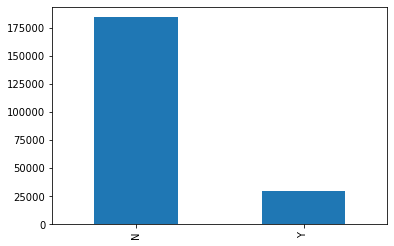

In [13]:
df['FirstTimeHomebuyer'].value_counts().plot.bar()

In [14]:
df = df.reset_index(drop=True)

In [15]:
df

,CreditScore,FirstTimeHomebuyer,MIP,Units,OCLTV,DTI,OrigUPB,LTV,OrigInterestRate,OrigLoanTerm,EverDelinquent,MonthsDelinquent,MonthsInRepayment
0,0,N,25,1,89,27,117000,89,6.750,360,0,0,52
1,0,N,0,1,73,17,109000,73,6.500,360,0,0,144
2,0,N,0,1,75,16,88000,75,6.875,360,0,0,67
3,0,N,0,1,76,14,160000,76,6.875,360,0,0,35
4,0,N,0,1,78,18,109000,78,7.125,360,0,0,54
...,...,...,...,...,...,...,...,...,...,...,...,...,...
213431,839,N,0,1,60,32,90000,60,7.000,360,0,0,12
213432,840,N,0,1,73,0,267000,73,6.375,319,0,0,53
213433,840,N,0,1,73,31,87000,73,5.625,313,0,0,38
213434,845,N,0,1,80,54,88000,80,7.000,360,0,0,32


# Balance FirstTimeHomebuyer

AxesSubplot(0.125,0.125;0.775x0.755)
N    184154
Y     29282
Name: FirstTimeHomebuyer, dtype: int64


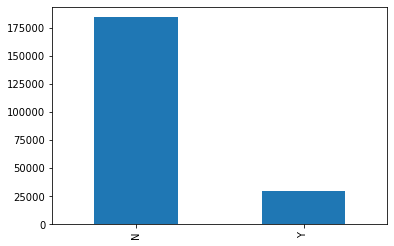

In [16]:
print(df['FirstTimeHomebuyer'].value_counts().plot.bar())
print(df['FirstTimeHomebuyer'].value_counts())

In [17]:
from imblearn.combine import SMOTETomek
res_over_und= SMOTETomek(sampling_strategy=0.7)
X_t_res, Y_t_res = res_over_und.fit_resample(df.loc[:,df.columns!='FirstTimeHomebuyer'],df.loc[:,df.columns=='FirstTimeHomebuyer'])

<AxesSubplot:xlabel='FirstTimeHomebuyer'>

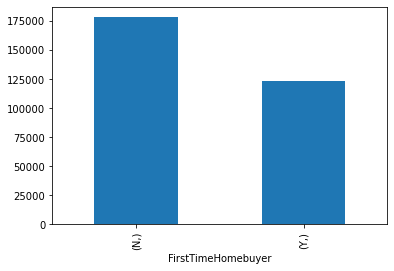

In [18]:
Y_t_res.value_counts().plot.bar()

In [19]:
df = pd.concat([X_t_res,Y_t_res],axis=1)

In [20]:
df['FirstTimeHomebuyer'].value_counts()

N    178358
Y    123111
Name: FirstTimeHomebuyer, dtype: int64

#  Categorical preprocess

In [21]:
from sklearn.preprocessing import OneHotEncoder
from collections import defaultdict
enc = OneHotEncoder()
X = df[['FirstTimeHomebuyer']]
df = df.drop('FirstTimeHomebuyer',axis=1)
enc.fit(X)

OneHotEncoder()

In [22]:
FirstTimeHomebuyervariable = enc.transform(X).toarray()


In [23]:
FirstTimeHomebuyervariable

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [0., 1.],
       [0., 1.],
       [0., 1.]])

In [24]:
onehot= pd.DataFrame(FirstTimeHomebuyervariable)
df = df.join(onehot)

In [25]:
df

,CreditScore,MIP,Units,OCLTV,DTI,OrigUPB,LTV,OrigInterestRate,OrigLoanTerm,EverDelinquent,MonthsDelinquent,MonthsInRepayment,0,1
0,0,25,1,89,27,117000,89,6.750000,360,0,0,52,1.0,0.0
1,0,0,1,73,17,109000,73,6.500000,360,0,0,144,1.0,0.0
2,0,0,1,75,16,88000,75,6.875000,360,0,0,67,1.0,0.0
3,0,0,1,76,14,160000,76,6.875000,360,0,0,35,1.0,0.0
4,0,0,1,78,18,109000,78,7.125000,360,0,0,54,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301464,664,30,1,95,30,115000,95,6.897724,360,0,0,30,0.0,1.0
301465,766,12,1,85,27,112000,85,6.787248,360,0,0,51,0.0,1.0
301466,701,32,1,95,37,157000,95,7.337129,360,0,0,27,0.0,1.0
301467,754,0,1,67,45,55000,67,7.215749,360,0,0,130,0.0,1.0


# Quantitave Preprocess

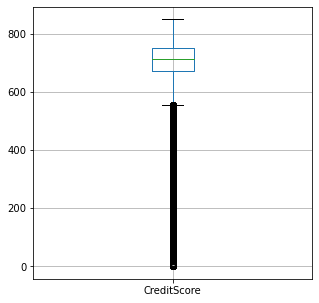

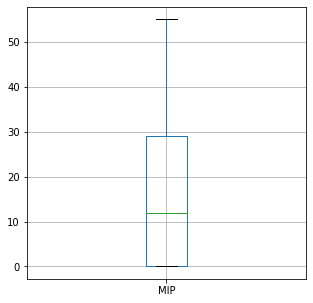

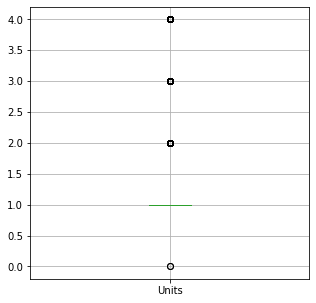

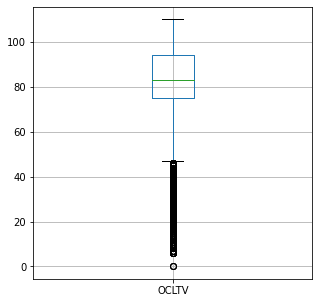

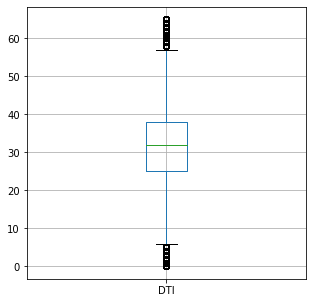

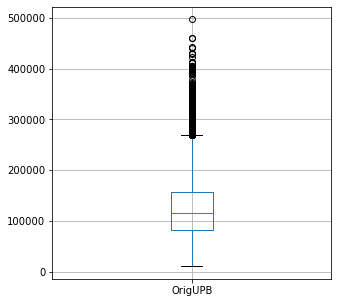

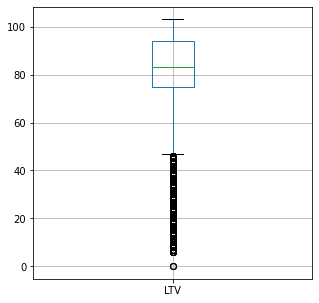

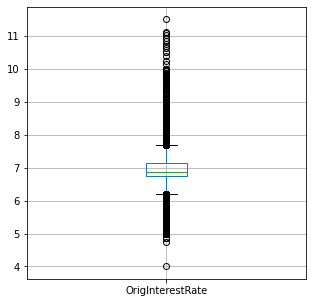

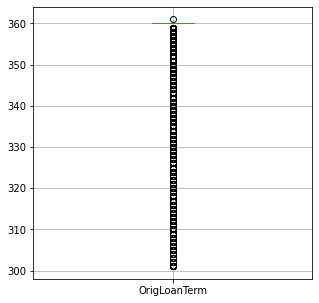

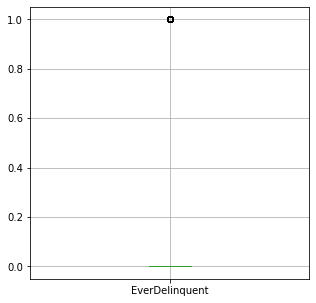

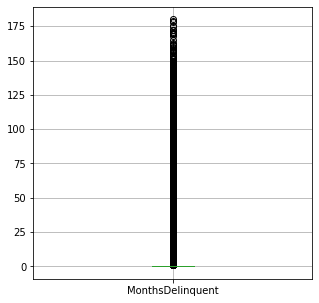

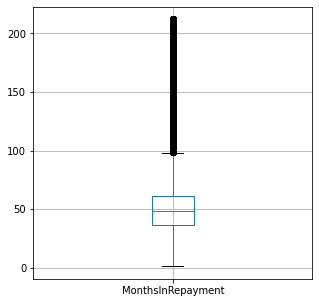

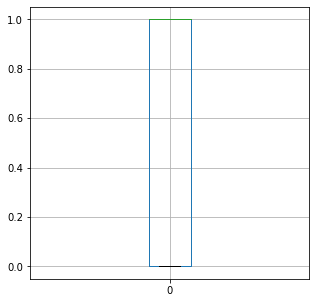

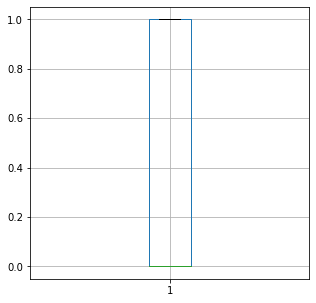

In [26]:
for i in df.columns:
    plt.figure(figsize=(5,5))
    df.boxplot([i])
    plt.show()

## OUTLIERS

###  OrigUPB

In [27]:
def outliersQ(name, df_quantitave):
    print("Name  ",name)
    Q1= df_quantitave[name].quantile(0.25)
    print("First cuartil:",Q1)

    Q3= df_quantitave[name].quantile(0.75)
    print("Third cuartil:",Q3)

    Q2_median= df_quantitave[name].median()
    print("Median:",Q2_median)

    Valor_min= df_quantitave[name].min()
    print("value min:",Valor_min)

    Valor_max= df_quantitave[name].max()
    print("value max:",Valor_max)
    IQR= Q3-Q1
    print("range iqr:",IQR)
    binf=(Q1 - 1.5 * IQR)
    print("value inf:",binf)                                     
    bsup=(Q3 + 1.5*IQR)
    print("value sup:",bsup)
    inlier= (df_quantitave[name]>binf) & ( df_quantitave[name]<bsup)
    df_aux = df_quantitave[inlier]
    diference = len(df_aux)/len(df_quantitave) *100
    print(diference)
    return df_aux

In [28]:
variablesOutliers =['OrigUPB']

In [29]:
for i in variablesOutliers:
    df_aux = outliersQ(i,df)
    df_quantitave = df_aux

Name   OrigUPB
First cuartil: 82000.0
Third cuartil: 157000.0
Median: 116000.0
value min: 10000
value max: 497000
range iqr: 75000.0
value inf: -30500.0
value sup: 269500.0
99.59166614146065


## Months in Repayment

In [30]:
df['MonthsInRepayment'].value_counts()

50     8846
49     8834
48     8594
51     8503
45     8462
       ... 
191     164
200     163
185     158
180     157
203     153
Name: MonthsInRepayment, Length: 212, dtype: int64

In [31]:
def levels_month(month):
    year = month/12
    if year<=4:
        return 1
    if year>4 and year <=8:
        return 2
    if year>8 and year <=12:
        return 3
    if year>12 and year <=16:
        return 4
    if year>16 and year <21:
        return 5

In [32]:
df['RepayRange']= df['MonthsInRepayment'].apply(levels_month)

<AxesSubplot:>

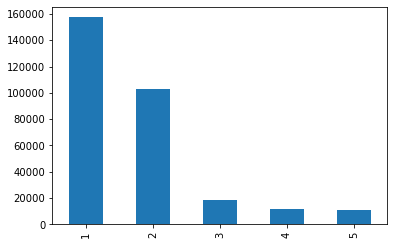

In [33]:
fig, ax = plt.subplots()
df['RepayRange'].value_counts().plot(ax=ax, kind='bar')

In [34]:
from imblearn.under_sampling import NearMiss
unds = NearMiss()
X_t_res, Y_t_res = unds.fit_resample(df.loc[:,df.columns!='RepayRange'],df.loc[:,df.columns=='RepayRange'])

/home/david/.local/lib/python3.8/site-packages/sklearn/utils/validation.py:1858: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(


<AxesSubplot:xlabel='RepayRange'>

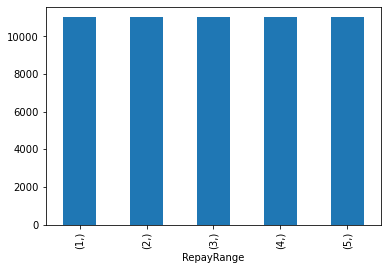

In [35]:
fig, ax = plt.subplots()
Y_t_res.value_counts().plot(ax=ax, kind='bar')

In [36]:
df = pd.concat([X_t_res,Y_t_res],axis=1)

In [37]:
df

,CreditScore,MIP,Units,OCLTV,DTI,OrigUPB,LTV,OrigInterestRate,OrigLoanTerm,EverDelinquent,MonthsDelinquent,MonthsInRepayment,0,1,RepayRange
0,659,0,1,80,17,75000,80,6.875000,360,0,0,48,1.0,0.0,1
1,759,30,1,95,30,104000,95,6.779522,360,0,0,48,0.0,1.0,1
2,758,30,1,95,30,104000,95,6.737405,360,0,0,48,0.0,1.0,1
3,773,25,1,90,34,104000,90,6.750000,360,0,0,48,0.0,1.0,1
4,773,25,1,90,33,104000,90,6.750000,360,0,0,48,0.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55040,636,30,1,93,25,168000,93,7.088642,360,1,60,199,0.0,1.0,5
55041,680,24,1,91,38,76000,91,7.218119,360,0,2,211,0.0,1.0,5
55042,627,26,1,91,32,59000,91,6.839666,360,0,6,206,0.0,1.0,5
55043,637,23,1,90,22,68000,90,7.159469,360,0,0,210,0.0,1.0,5


## LTV

In [38]:
def ltv_range(value):
    if value< 26:
        return 1
    if value<51 and value > 25:
        return 2
    if value > 50:
        return 3

In [39]:
df['ltvRange']= df['LTV'].apply(ltv_range)

<AxesSubplot:>

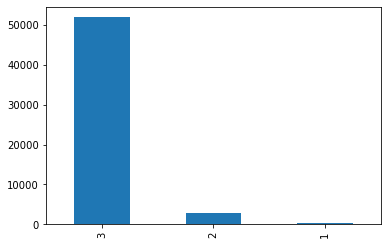

In [40]:
fig, ax = plt.subplots()
df['ltvRange'].value_counts().plot(ax=ax, kind='bar')

### balance ltv

In [41]:
res_over_und= SMOTETomek(sampling_strategy={3:51934, 2:37000,1:30000})
X_t_res, Y_t_res = res_over_und.fit_resample(df.loc[:,df.columns!='ltvRange'],df.loc[:,df.columns=='ltvRange'])

/home/david/.local/lib/python3.8/site-packages/sklearn/utils/validation.py:1858: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(
/home/david/anaconda3/envs/pythonClass/lib/python3.8/site-packages/imblearn/utils/_validation.py:318: UserWarning: After over-sampling, the number of samples (51934) in class 3 will be larger than the number of samples in the majority class (class #3 -> 51837)
  warnings.warn(
/home/david/anaconda3/envs/pythonClass/lib/python3.8/site-packages/imblearn/utils/_validation.py:318: UserWarning: After over-sampling, the number of samples (51934) in class 3 will be larger than the number of samples in the majority class (class #3 -> 51837)
  warnings.warn(


<AxesSubplot:xlabel='ltvRange'>

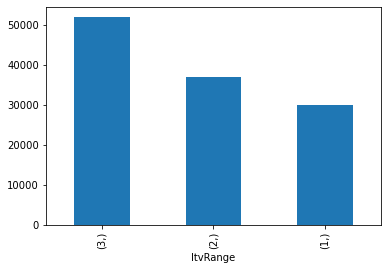

In [42]:
fig, ax = plt.subplots()
Y_t_res.value_counts().plot(ax=ax, kind='bar')

In [43]:
df = pd.concat([X_t_res,Y_t_res],axis=1)

In [44]:
df

,CreditScore,MIP,Units,OCLTV,DTI,OrigUPB,LTV,OrigInterestRate,OrigLoanTerm,EverDelinquent,MonthsDelinquent,MonthsInRepayment,0,1,RepayRange,ltvRange
0,659,0,1,80,17,75000,80,6.875000,360,0,0,48,1.000000,0.000000,1,3
1,759,30,1,95,30,104000,95,6.779522,360,0,0,48,0.000000,1.000000,1,3
2,758,30,1,95,30,104000,95,6.737405,360,0,0,48,0.000000,1.000000,1,3
3,773,25,1,90,34,104000,90,6.750000,360,0,0,48,0.000000,1.000000,1,3
4,773,25,1,90,33,104000,90,6.750000,360,0,0,48,0.000000,1.000000,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118721,696,29,1,90,32,100000,90,7.006513,360,1,1,179,0.000000,1.000000,4,3
118722,744,25,1,90,22,112000,90,6.500000,360,0,0,78,1.000000,0.000000,2,3
118723,696,0,1,70,16,132000,70,6.711360,360,0,0,210,1.000000,0.000000,5,3
118724,692,29,1,94,46,83000,94,6.628947,360,0,0,209,0.982173,0.017827,5,3


## Credit

In [45]:
df.CreditScore.unique()

array([659, 759, 758, 773, 769, 662, 761, 667, 755, 669, 770, 690, 692,
       762, 694, 691, 679, 765, 767, 696, 739, 654, 748, 779, 746, 697,
       753, 683, 771, 774, 781, 729, 756, 777, 665, 763, 660, 630, 668,
       642, 740, 641, 700, 688, 709, 636, 751, 752, 675, 682, 742, 720,
       757, 735, 741, 635, 723, 632, 693, 634, 768, 737, 684, 733, 754,
       664, 747, 778, 685, 705, 749, 745, 744, 708, 764, 674, 743, 663,
       760, 736, 686, 649, 710, 653, 695, 734, 784, 772, 699, 678, 650,
       631, 714, 702, 646, 717, 706, 661, 647, 666, 766, 731, 624, 701,
       722, 738, 730, 673, 703, 628, 780, 727, 655, 721, 658, 704, 726,
       680, 644, 725, 707, 623, 672, 789, 803, 713, 790, 791, 640, 732,
       792, 776, 797, 750, 775, 681, 715, 677, 798, 716, 795, 785, 656,
       724, 689, 728, 786, 645, 651, 592, 719, 676, 657, 711, 639, 782,
       687, 638, 633, 670, 809, 606, 627, 783, 629, 712, 637, 671, 718,
       626, 652, 616, 648, 808, 625, 618, 621, 788, 698, 619, 79

In [46]:
def credit_range(value):
    if value <= 650:
        return 1
    if value > 650 and value <=700:
        return 2
    if value>700 and value <=750:
        return 3
    if value >750:
        return 4

In [47]:
df['creditRange']= df['CreditScore'].apply(credit_range)

<AxesSubplot:>

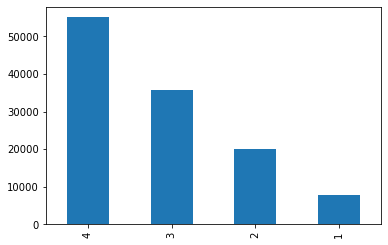

In [48]:
fig, ax = plt.subplots()
df['creditRange'].value_counts().plot(ax=ax, kind='bar')

## Months Delinquence

In [49]:
df['MonthsDelinquent'].value_counts()

0      91122
1       8996
2       3375
3       2002
4       1309
       ...  
179        1
165        1
178        1
160        1
154        1
Name: MonthsDelinquent, Length: 173, dtype: int64

In [50]:
def levels_monthD(month):
    year = month/12
    if year<=4:
        return 1
    if year>4 and year <=16:
        return 2
df['MonthsDelinquentRange']= df['MonthsDelinquent'].apply(levels_monthD)

### We use only 2 range because the last range have a little amount of data

<AxesSubplot:>

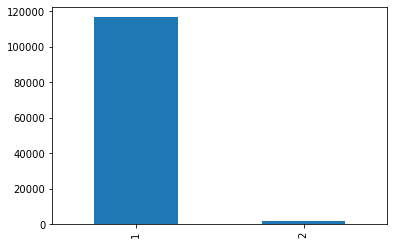

In [51]:
fig, ax = plt.subplots()
df['MonthsDelinquentRange'].value_counts().plot(ax=ax, kind='bar')

In [52]:
df['MonthsDelinquentRange'].value_counts()

1    116677
2      2049
Name: MonthsDelinquentRange, dtype: int64

In [53]:
res_over_und= SMOTETomek(sampling_strategy={1:116710, 2:60000})
X_t_res, Y_t_res = res_over_und.fit_resample(df.loc[:,df.columns!='MonthsDelinquentRange'],df.loc[:,df.columns=='MonthsDelinquentRange'])

/home/david/.local/lib/python3.8/site-packages/sklearn/utils/validation.py:1858: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(
/home/david/anaconda3/envs/pythonClass/lib/python3.8/site-packages/imblearn/utils/_validation.py:318: UserWarning: After over-sampling, the number of samples (116710) in class 1 will be larger than the number of samples in the majority class (class #1 -> 116677)
  warnings.warn(
/home/david/anaconda3/envs/pythonClass/lib/python3.8/site-packages/imblearn/utils/_validation.py:318: UserWarning: After over-sampling, the number of samples (116710) in class 1 will be larger than the number of samples in the majority class (class #1 -> 116677)
  warnings.warn(


In [54]:
df = pd.concat([X_t_res,Y_t_res],axis=1)

<AxesSubplot:xlabel='MonthsDelinquentRange'>

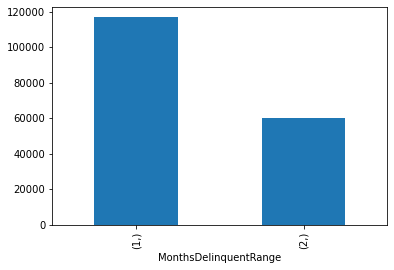

In [55]:
fig, ax = plt.subplots()
Y_t_res.value_counts().plot(ax=ax, kind='bar')

In [56]:
len(Y_t_res)

176692

# Balance

## Target value EverDelinquent

<AxesSubplot:>

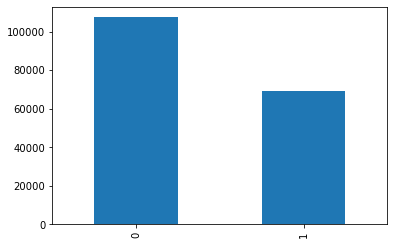

In [57]:
fig, ax = plt.subplots()
df['EverDelinquent'].value_counts().plot(ax=ax, kind='bar')

In [58]:
df['CreditScore'].unique()

array([659, 759, 758, 773, 769, 662, 761, 667, 755, 669, 770, 690, 692,
       762, 694, 691, 679, 765, 767, 696, 739, 654, 748, 779, 746, 697,
       753, 683, 771, 774, 781, 729, 756, 777, 665, 763, 660, 630, 668,
       642, 740, 641, 700, 688, 709, 636, 751, 752, 675, 682, 742, 720,
       757, 735, 741, 635, 723, 632, 693, 634, 768, 737, 684, 733, 754,
       664, 747, 778, 685, 705, 749, 745, 744, 708, 764, 674, 743, 663,
       760, 736, 686, 649, 710, 653, 695, 734, 784, 772, 699, 678, 650,
       631, 714, 702, 646, 717, 706, 661, 647, 666, 766, 731, 624, 701,
       722, 738, 730, 673, 703, 628, 780, 727, 655, 721, 658, 704, 726,
       680, 644, 725, 707, 623, 672, 789, 803, 713, 790, 791, 640, 732,
       792, 776, 797, 750, 775, 681, 715, 677, 798, 716, 795, 785, 656,
       724, 689, 728, 786, 645, 651, 592, 719, 676, 657, 711, 639, 782,
       687, 638, 633, 670, 809, 606, 627, 783, 629, 712, 637, 671, 718,
       626, 652, 616, 648, 808, 625, 618, 621, 788, 698, 619, 79

<AxesSubplot:>

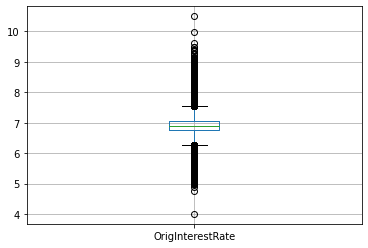

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
pd.DataFrame(df['OrigInterestRate']).boxplot(['OrigInterestRate'])

In [60]:
print(max(df['OrigInterestRate']))
print(min(df['OrigInterestRate']))

10.5
4.0


# Multivariate Analisis

## Insights

In [62]:
a = df.loc[:,['creditRange','EverDelinquent']].groupby('creditRange', group_keys=True)
visualice = pd.DataFrame()
visualice['1'] = a.mean()
visualice['0'] = 1-a.mean()
print(visualice)

                    1         0
creditRange                    
1            0.820807  0.179193
2            0.597303  0.402697
3            0.210082  0.789918
4            0.056069  0.943931


<AxesSubplot:xlabel='creditRange'>

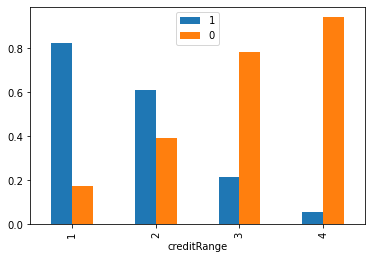

In [63]:
visualice.plot.bar()

## We see that if we have more credit decrease the people that's gonna pay in time

## Months Repayment Range

In [64]:
b = df.loc[:,['RepayRange','EverDelinquent']].groupby('RepayRange', group_keys=True)

In [65]:
visualice = pd.DataFrame()
visualice['1'] = b.mean()
visualice['0'] = 1-b.mean()
print(visualice)

                   1         0
RepayRange                    
1           0.066589  0.933411
2           0.242557  0.757443
3           0.193433  0.806567
4           0.426124  0.573876
5           0.661709  0.338291


<AxesSubplot:xlabel='RepayRange'>

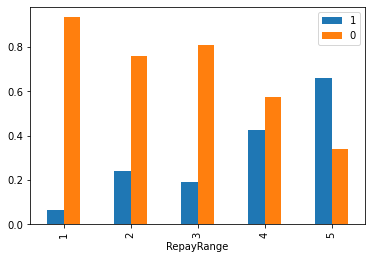

In [66]:
visualice.plot.bar()

## We see that the most people pay on the last range month (more time)

## Months Delinquent Range

In [67]:
b = df.loc[:,['MonthsDelinquentRange','EverDelinquent']].groupby('MonthsDelinquentRange', group_keys=True)

In [68]:
visualice = pd.DataFrame()
visualice['1'] = b.mean()
visualice['0'] = 1-b.mean()
print(visualice)

                              1         0
MonthsDelinquentRange                    
1                      0.131827  0.868173
2                      0.893923  0.106077


<AxesSubplot:xlabel='MonthsDelinquentRange'>

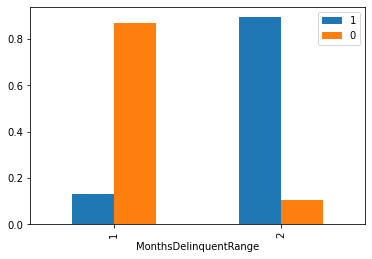

In [69]:
visualice.plot.bar()

In [70]:
df[50:100]

,CreditScore,MIP,Units,OCLTV,DTI,OrigUPB,LTV,OrigInterestRate,OrigLoanTerm,EverDelinquent,MonthsDelinquent,MonthsInRepayment,0,1,RepayRange,ltvRange,creditRange,MonthsDelinquentRange
50,737,30,1,95,30,104000,95,7.500000,360,1,1,48,0.0,1.0,1,3,3,1
51,640,30,1,95,37,140000,95,7.230511,360,1,1,48,0.0,1.0,1,3,1,1
52,777,30,1,95,40,104000,95,7.000000,360,0,0,47,1.0,0.0,1,3,4,1
53,639,28,1,93,37,140000,93,7.156643,360,0,1,48,0.0,1.0,1,3,1,1
54,769,0,1,58,30,100000,58,6.875000,360,0,0,48,1.0,0.0,1,3,4,1
55,757,21,1,88,24,72000,88,6.957848,360,0,0,48,0.0,1.0,1,3,4,1
56,705,0,1,78,30,120000,78,6.625000,360,0,0,47,1.0,0.0,1,3,3,1
57,763,0,1,55,29,100000,55,6.500000,360,0,0,48,1.0,0.0,1,3,4,1
58,638,28,1,93,36,140000,93,7.199260,360,0,1,48,0.0,1.0,1,3,1,1
59,759,0,1,61,31,100000,61,6.625000,360,0,0,48,1.0,0.0,1,3,4,1


## We see that the people that was delinquent ocurre on the first range and give them more time to pay

In [74]:
def graphicMult(df, variable):
    b = df.loc[:,[variable,'EverDelinquent']].groupby([variable], group_keys=True)
    visualice = pd.DataFrame()
    visualice['1'] = b.mean()
    visualice['0'] = 1-b.mean()
    visualice.plot.bar()

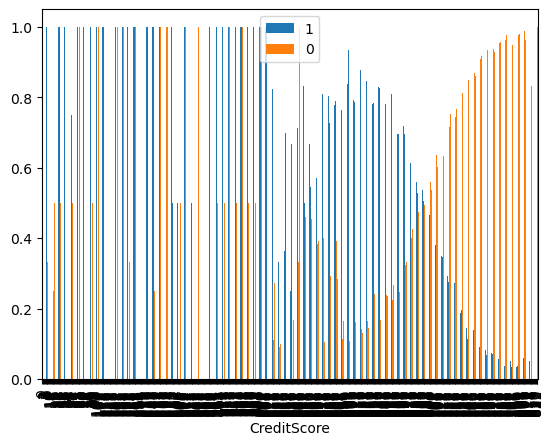

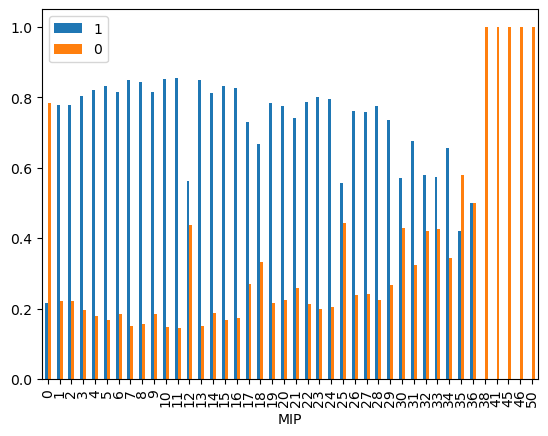

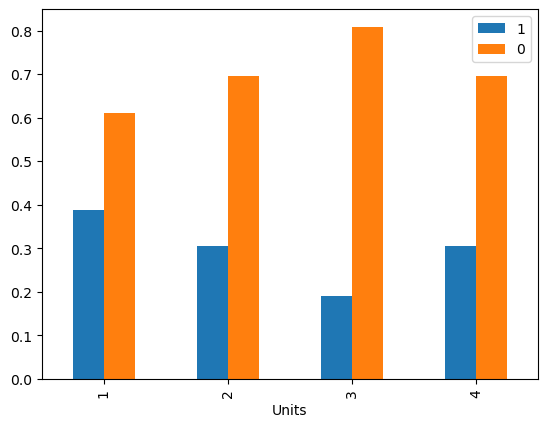

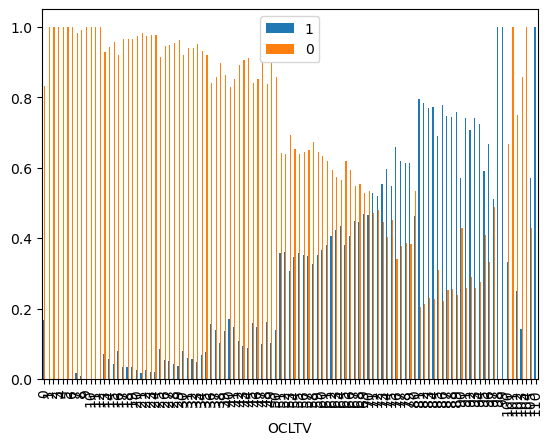

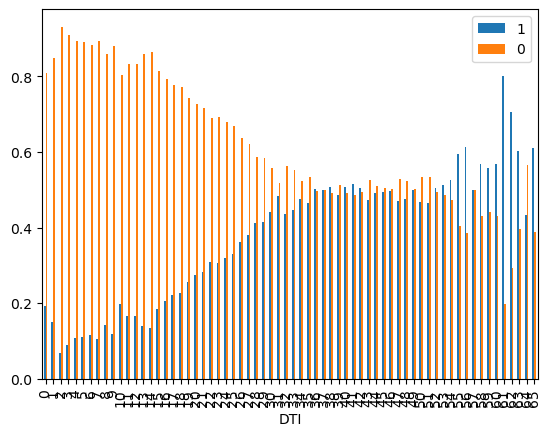

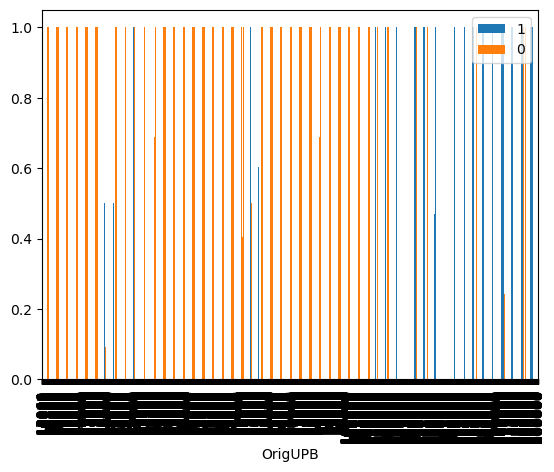

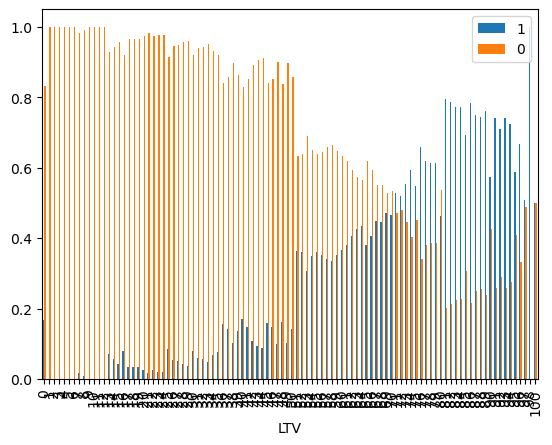

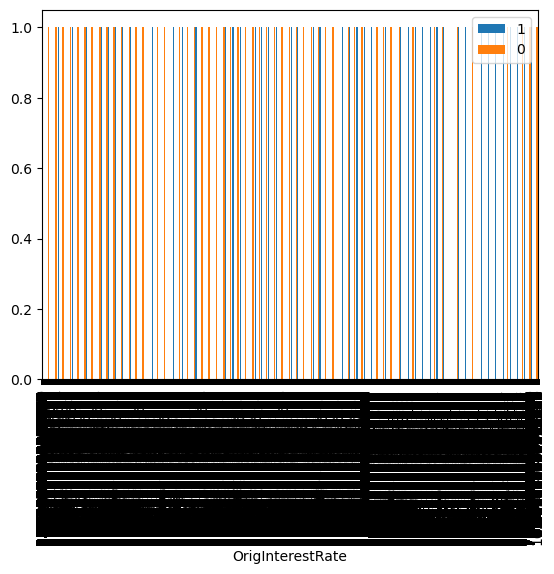

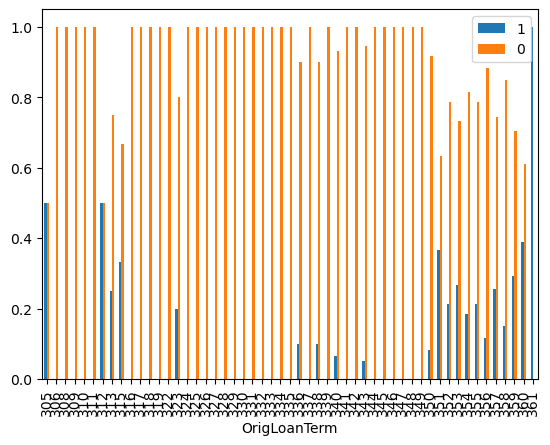

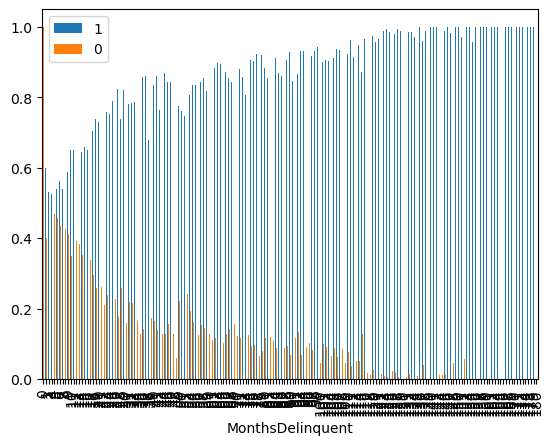

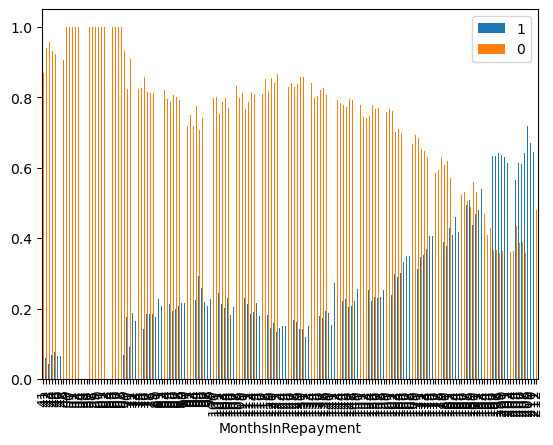

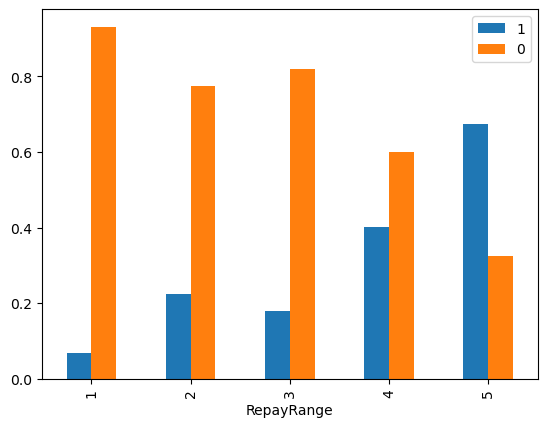

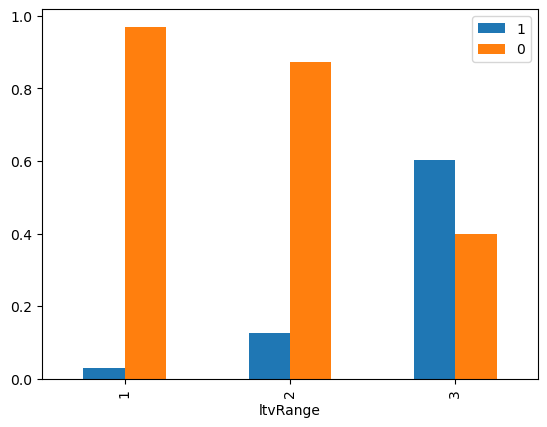

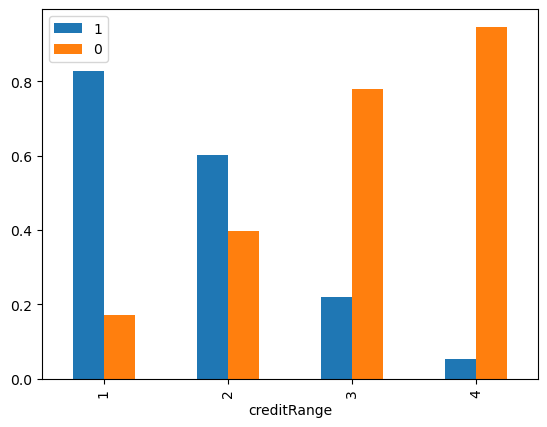

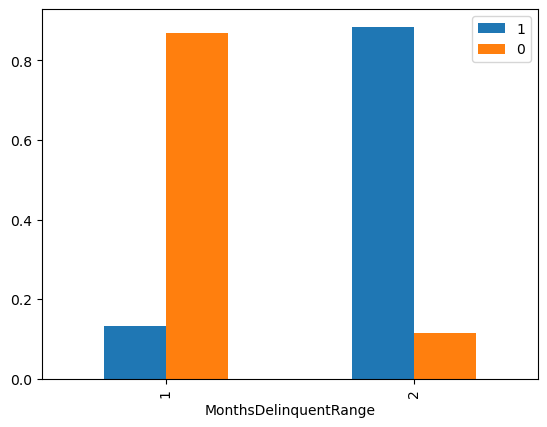

In [75]:
for i in df.columns[df.columns!='EverDelinquent']:
    graphicMult(df,i)

# univariate analysis

In [74]:
df

,CreditScore,MIP,Units,OCLTV,DTI,OrigUPB,LTV,OrigInterestRate,OrigLoanTerm,EverDelinquent,MonthsDelinquent,MonthsInRepayment,RepayRange,ltvRange,creditRange,MonthsDelinquentRange
0,769,30,1,95,44,104000,95,6.750000,360,0,0,48,1,3,4,1
1,764,22,1,96,25,104000,96,7.529963,360,0,1,48,1,3,4,1
2,761,25,1,90,25,104000,90,7.000000,360,0,0,48,1,3,4,1
3,756,25,1,90,28,104000,90,6.800006,360,0,0,48,1,3,4,1
4,694,0,1,76,27,64000,76,7.375000,360,1,1,48,1,3,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176443,654,0,1,20,44,16664,20,8.459090,360,0,77,194,5,1,2,2
176444,721,11,1,81,39,131000,81,6.780656,360,1,64,205,5,3,2,2
176445,643,0,1,79,36,86000,79,6.769250,360,1,98,208,5,3,1,2
176446,661,1,1,80,13,66000,80,6.916207,360,1,86,176,4,3,1,2


<AxesSubplot:ylabel='Frequency'>

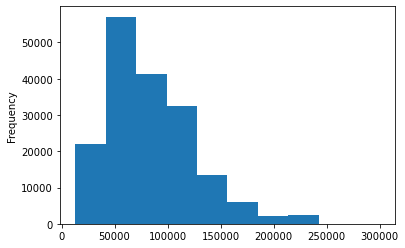

In [75]:
df['OrigUPB'].plot.hist()

<AxesSubplot:>

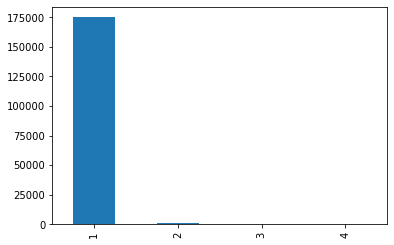

In [76]:
df['Units'].value_counts().plot.bar()

<AxesSubplot:ylabel='Frequency'>

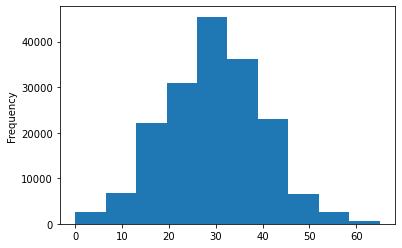

In [77]:
df['DTI'].plot.hist()

<AxesSubplot:ylabel='Frequency'>

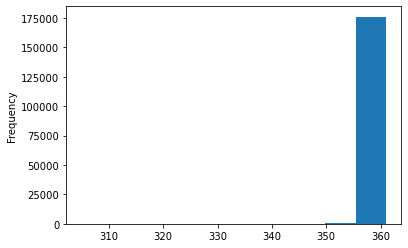

In [78]:
df['OrigLoanTerm'].plot.hist()

In [90]:
df.columns

Index(['CreditScore', 'MIP', 'Units', 'OCLTV', 'DTI', 'OrigUPB', 'LTV',
       'OrigInterestRate', 'OrigLoanTerm', 'EverDelinquent',
       'MonthsDelinquent', 'MonthsInRepayment', 'RepayRange', 'ltvRange',
       'creditRange', 'MonthsDelinquentRange'],
      dtype='object')

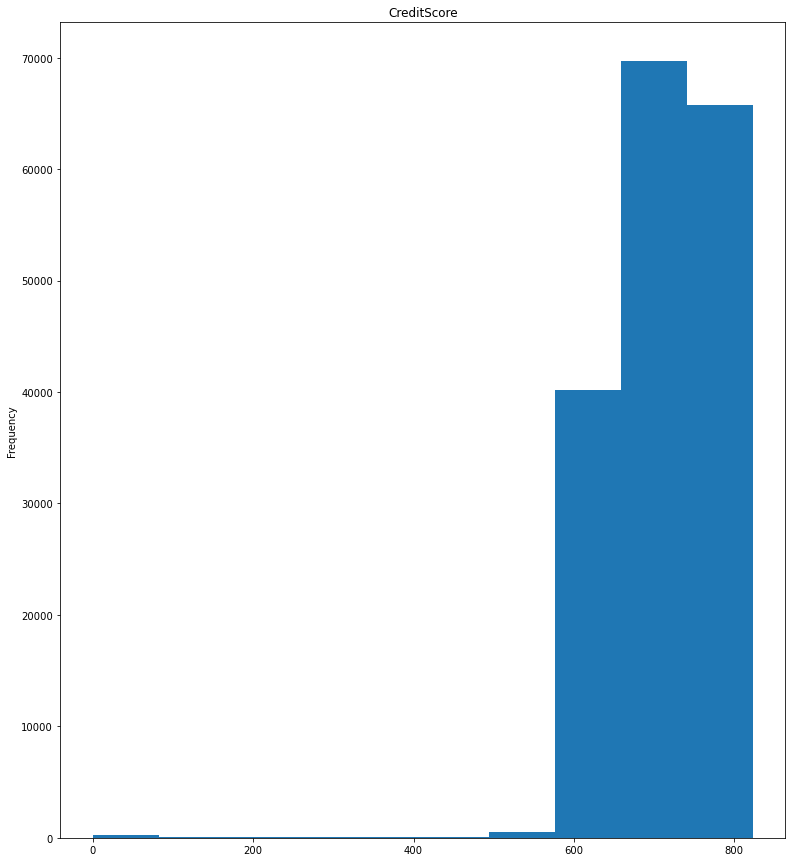

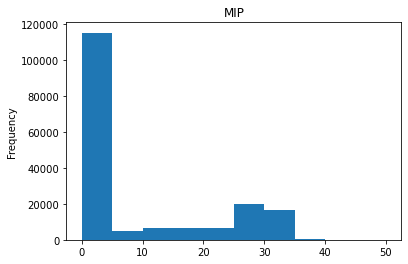

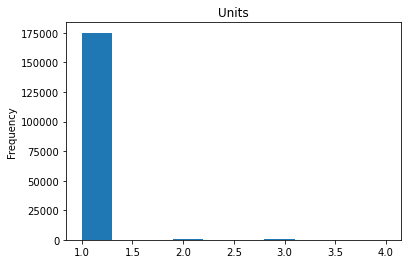

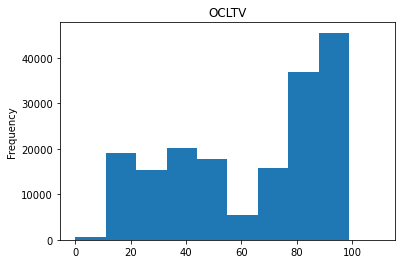

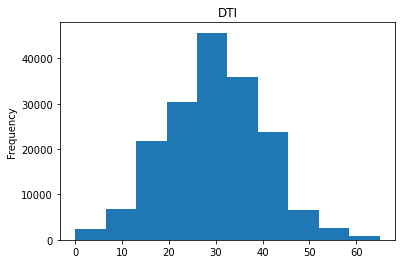

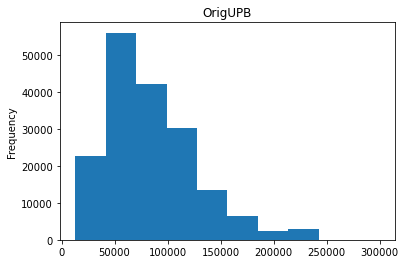

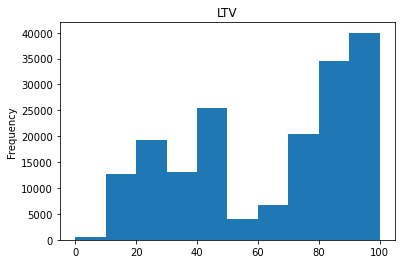

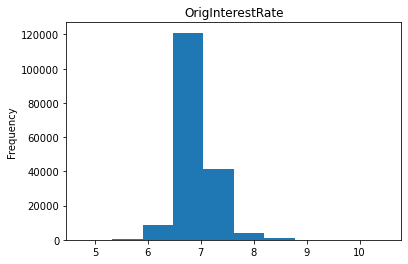

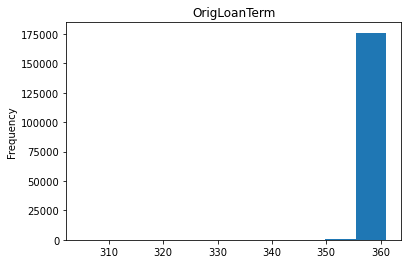

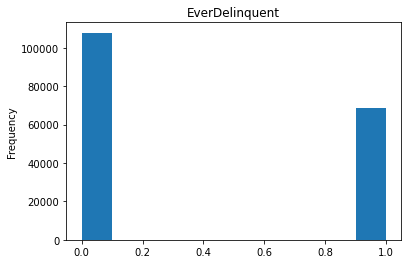

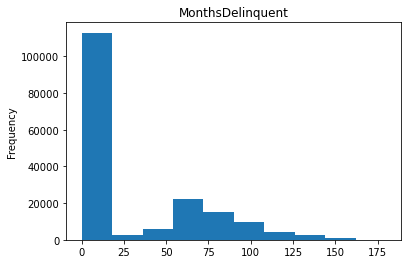

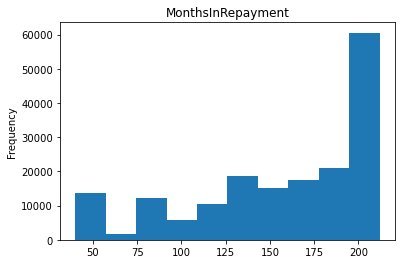

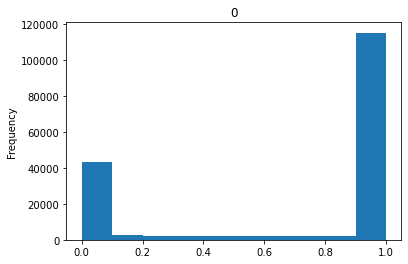

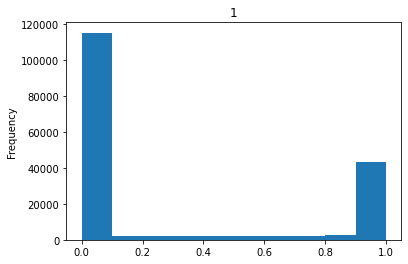

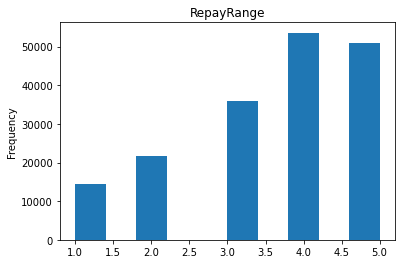

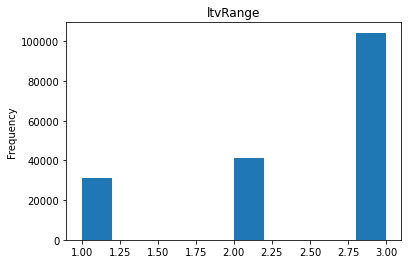

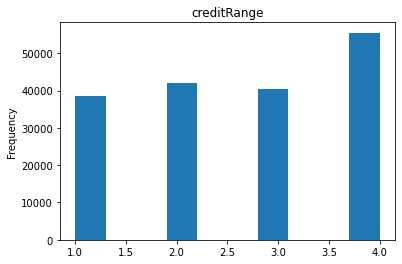

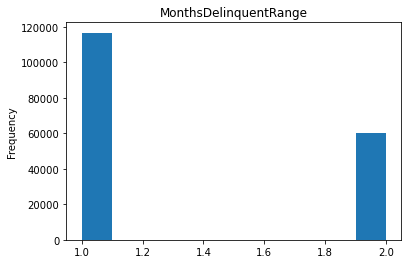

In [66]:
plt.figure(figsize=(13,15))
for i,column in enumerate(df.columns):
    df[column].plot.hist()
    plt.title(column)
    plt.show()

# Scale Data

In [61]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(df.loc[:,df.columns!='EverDelinquent'])

/home/david/.local/lib/python3.8/site-packages/sklearn/utils/validation.py:1858: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(
/home/david/.local/lib/python3.8/site-packages/sklearn/utils/validation.py:1858: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(


In [62]:
X_train

array([[-0.76624246, -0.67502783, -0.08421943, ...,  0.759843  ,
        -0.56696904, -0.71697789],
       [ 0.76562847,  1.86880513, -0.08421943, ...,  0.759843  ,
         1.18588114, -0.71697789],
       [ 0.75030976,  1.86880513, -0.08421943, ...,  0.759843  ,
         1.18588114, -0.71697789],
       ...,
       [-0.64369279, -0.67502783, -0.08421943, ...,  0.759843  ,
        -1.44339413,  1.39474315],
       [-0.9960231 ,  1.86880513, -0.08421943, ...,  0.759843  ,
        -1.44339413,  1.39474315],
       [-1.05729794, -0.25105567, -0.08421943, ...,  0.759843  ,
        -1.44339413,  1.39474315]])

# Feature selection

## Correlation

In [63]:
corr = df.corr(method='pearson')
corr

,CreditScore,MIP,Units,OCLTV,DTI,OrigUPB,LTV,OrigInterestRate,OrigLoanTerm,EverDelinquent,MonthsDelinquent,MonthsInRepayment,0,1,RepayRange,ltvRange,creditRange,MonthsDelinquentRange
CreditScore,1.000000,-0.375747,0.032515,-0.498199,-0.229500,-0.163116,-0.498163,-0.225174,-0.010214,-0.522016,-0.558094,-0.236456,0.242515,-0.242515,-0.239542,-0.459161,0.863866,-0.556571
MIP,-0.375747,1.000000,-0.040728,0.706607,0.187672,0.199053,0.706966,0.180627,0.026196,0.370983,0.392401,0.054388,-0.468444,0.468444,0.078749,0.511327,-0.415126,0.378091
Units,0.032515,-0.040728,1.000000,-0.030508,0.006117,0.024253,-0.030469,0.011265,-0.001856,-0.023923,-0.052039,-0.003207,0.041905,-0.041905,-0.001730,-0.018262,0.040047,-0.055425
OCLTV,-0.498199,0.706607,-0.030508,1.000000,0.272113,0.398268,0.999875,0.119125,0.016646,0.536716,0.488334,0.029588,-0.508660,0.508660,0.082630,0.940324,-0.561862,0.486771
DTI,-0.229500,0.187672,0.006117,0.272113,1.000000,0.175540,0.271636,0.140617,0.010538,0.217450,0.217930,0.028216,-0.097967,0.097967,0.039560,0.264642,-0.272537,0.213386
OrigUPB,-0.163116,0.199053,0.024253,0.398268,0.175540,1.000000,0.397884,-0.193393,-0.015603,0.182830,0.177206,-0.048974,-0.083130,0.083130,-0.031576,0.418073,-0.207658,0.156218
LTV,-0.498163,0.706966,-0.030469,0.999875,0.271636,0.397884,1.000000,0.119341,0.016748,0.536721,0.488554,0.029608,-0.508896,0.508896,0.082612,0.940458,-0.561795,0.487008
OrigInterestRate,-0.225174,0.180627,0.011265,0.119125,0.140617,-0.193393,0.119341,1.000000,0.026610,0.177567,0.270262,0.067818,-0.060107,0.060107,0.065897,0.069147,-0.255186,0.266770
OrigLoanTerm,-0.010214,0.026196,-0.001856,0.016646,0.010538,-0.015603,0.016748,0.026610,1.000000,0.018599,0.019132,-0.002218,-0.023670,0.023670,-0.001070,0.008874,-0.010332,0.019041
EverDelinquent,-0.522016,0.370983,-0.023923,0.536716,0.217450,0.182830,0.536721,0.177567,0.018599,1.000000,0.730891,0.392928,-0.189944,0.189944,0.390304,0.502334,-0.624515,0.735724


<AxesSubplot:>

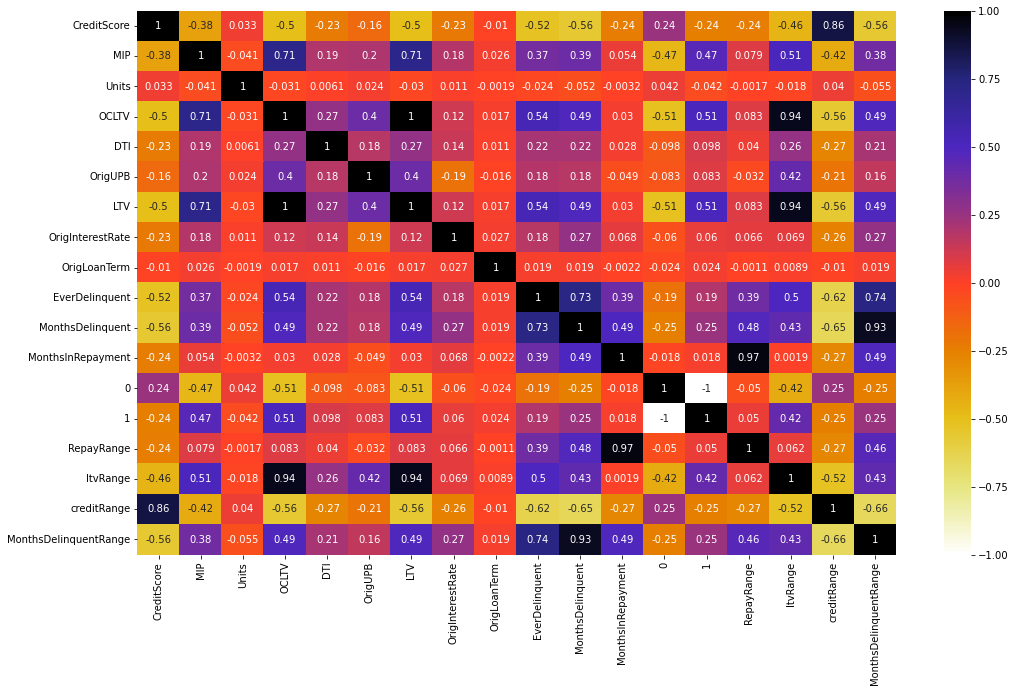

In [64]:
plt.figure(figsize=(17,10))
sns.heatmap(corr,annot=True,cmap=plt.cm.CMRmap_r)

In [65]:
def correlation(dataset, threshold):
    col_corr = set()  
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: 
                colname = corr_matrix.columns[i] 
                col_corr.add(colname)
    return col_corr

In [66]:
x = df.loc[:,df.columns!='EverDelinquent']
correlation(x,0.7)

{1,
 'LTV',
 'MonthsDelinquentRange',
 'OCLTV',
 'RepayRange',
 'creditRange',
 'ltvRange'}

### sometimes the dependency of our independents variables will take overfitting, but we are not gonna to delete them because is the dependency of the new variables that we create.

In [67]:
from sklearn.feature_selection import mutual_info_classif
mutual_info = mutual_info_classif(x,df.loc[:,df.columns=='EverDelinquent'].values.ravel())
mutual_info

array([0.21564455, 0.12667542, 0.02145842, 0.18644646, 0.03067149,
       0.08285911, 0.18709257, 0.0349997 , 0.02005929, 0.46463572,
       0.10303594, 0.05149698, 0.03986377, 0.09702044, 0.17087365,
       0.23215016, 0.31056868])

In [68]:
mutual_info=pd.Series(mutual_info)

In [69]:
mutual_info.index=x.columns

In [70]:
mutual_info.sort_values(ascending=False)

MonthsDelinquent         0.464636
MonthsDelinquentRange    0.310569
creditRange              0.232150
CreditScore              0.215645
LTV                      0.187093
OCLTV                    0.186446
ltvRange                 0.170874
MIP                      0.126675
MonthsInRepayment        0.103036
RepayRange               0.097020
OrigUPB                  0.082859
0                        0.051497
1                        0.039864
OrigInterestRate         0.035000
DTI                      0.030671
Units                    0.021458
OrigLoanTerm             0.020059
dtype: float64

In [71]:
mutual_info.sort_values(ascending=False)

MonthsDelinquent         0.464636
MonthsDelinquentRange    0.310569
creditRange              0.232150
CreditScore              0.215645
LTV                      0.187093
OCLTV                    0.186446
ltvRange                 0.170874
MIP                      0.126675
MonthsInRepayment        0.103036
RepayRange               0.097020
OrigUPB                  0.082859
0                        0.051497
1                        0.039864
OrigInterestRate         0.035000
DTI                      0.030671
Units                    0.021458
OrigLoanTerm             0.020059
dtype: float64

In [72]:
dropV = ['OrigUPB','OrigInterestRate','DTI','OrigLoanTerm','Units',0,1]
df.drop(dropV,axis=1)

,CreditScore,MIP,OCLTV,LTV,EverDelinquent,MonthsDelinquent,MonthsInRepayment,RepayRange,ltvRange,creditRange,MonthsDelinquentRange
0,659,0,80,80,0,0,48,1,3,2,1
1,759,30,95,95,0,0,48,1,3,4,1
2,758,30,95,95,0,0,48,1,3,4,1
3,773,25,90,90,0,0,48,1,3,4,1
4,773,25,90,90,0,0,48,1,3,4,1
...,...,...,...,...,...,...,...,...,...,...,...
176687,590,0,76,76,1,62,188,4,3,1,2
176688,630,5,83,83,1,135,209,5,3,1,2
176689,667,0,75,75,1,107,170,4,3,1,2
176690,644,30,95,95,1,78,208,5,3,1,2


### We drop the variables less than 0.09

# PCA

In [73]:
from sklearn.decomposition import PCA

In [76]:
pca =PCA(n_components=10)

In [77]:
pca = pca.fit(df.loc[:,df.columns!='EverDelinquent'])

/home/david/.local/lib/python3.8/site-packages/sklearn/utils/validation.py:1858: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  warnings.warn(


In [78]:
np.cumsum(pca.explained_variance_ratio_)

array([0.99999443, 0.99999761, 0.99999901, 0.99999959, 0.99999991,
       0.99999996, 1.        , 1.        , 1.        , 1.        ])

In [79]:
pca.explained_variance_

array([1.72474585e+09, 5.47870374e+03, 2.42341772e+03, 9.87296379e+02,
       5.52314670e+02, 9.63119737e+01, 6.39689832e+01, 1.11101294e+00,
       2.72489631e-01, 2.17405309e-01])

### we can see that with one variable obtain 99 percent of explain data

### we are gonna to choose mutual info function

In [74]:
df = df.drop(dropV,axis=1)

In [75]:
df

,CreditScore,MIP,OCLTV,LTV,EverDelinquent,MonthsDelinquent,MonthsInRepayment,RepayRange,ltvRange,creditRange,MonthsDelinquentRange
0,659,0,80,80,0,0,48,1,3,2,1
1,759,30,95,95,0,0,48,1,3,4,1
2,758,30,95,95,0,0,48,1,3,4,1
3,773,25,90,90,0,0,48,1,3,4,1
4,773,25,90,90,0,0,48,1,3,4,1
...,...,...,...,...,...,...,...,...,...,...,...
176687,590,0,76,76,1,62,188,4,3,1,2
176688,630,5,83,83,1,135,209,5,3,1,2
176689,667,0,75,75,1,107,170,4,3,1,2
176690,644,30,95,95,1,78,208,5,3,1,2


## random forest

In [76]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn import metrics

In [77]:
x = df.loc[:,df.columns!='EverDelinquent']
y=df.loc[:,df.columns=='EverDelinquent']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3, random_state=42) 

In [78]:
wqp_rf = RandomForestClassifier(random_state=0)#este objeto es de tipo función
wqp_rf.fit(x_train, y_train.values.ravel())

RandomForestClassifier(random_state=0)

In [79]:
predict = wqp_rf.predict(x_train)

In [80]:
predict_test= wqp_rf.predict(x_test)

In [81]:
train = confusion_matrix(y_train, predict)

In [81]:
test= confusion_matrix(y_test, predict_test)

## train

In [82]:
VN=train[1][1]
VP=train[0][0]
FP=train[0][1]
FN=train[1][0]
sens = VP/(VP+FN)
espc = VN/(VN+FP)
espc_1 = 1-espc
Acc= (VP+VN)/(VP+VN+FP+FN)

Text(0.5, 1.0, 'Curva ROC')

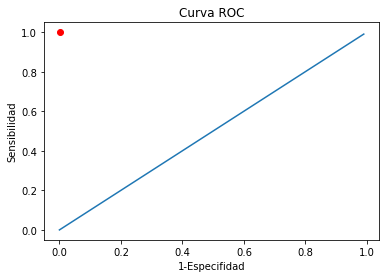

In [83]:
plt.plot(espc_1, 
         sens, 
         marker="o", 
         linestyle="--", 
         color="red")
x=[i*0.01 for i in range(100)]
y=[i*0.01 for i in range(100)]
plt.plot(x,y)
plt.xlabel("1-Especifidad")
plt.ylabel("Sensibilidad")
plt.title("Curva ROC")

## test

In [84]:
VN=test[1][1]
VP=test[0][0]
FP=test[0][1]
FN=test[1][0]
sens = VP/(VP+FN)
espc = VN/(VN+FP)
espc_1 = 1-espc
Acc= (VP+VN)/(VP+VN+FP+FN)

Text(0.5, 1.0, 'Curva ROC')

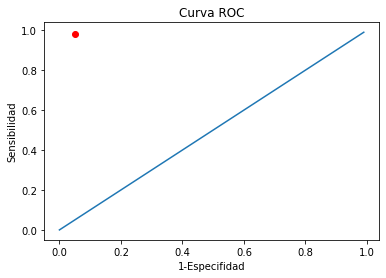

In [85]:
plt.plot(espc_1, 
         sens, 
         marker="o", 
         linestyle="--", 
         color="red")
x=[i*0.01 for i in range(100)]
y=[i*0.01 for i in range(100)]
plt.plot(x,y)
plt.xlabel("1-Especifidad")
plt.ylabel("Sensibilidad")
plt.title("Curva ROC")

In [86]:
from sklearn.metrics import precision_score
precision_score(y_train, predict)

0.9990977380502749

In [87]:
precision_random_forest = precision_score(y_test, predict_test)
precision_random_forest

0.9489766913018761

In [88]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, predict_test)

0.9679098986926254

## SVC

In [84]:
from sklearn import svm
clf = svm.SVC(kernel='linear', C = 1.0)
x =10000
y=0
for i in range(3):
    x_train_svc= x_train[y:x]
    y_train_svc=y_train[y:x]
    clf.fit(x_train_svc,y_train_svc.values.ravel())
    y=x
    x+=10000
    print('x:',x)
    print('i:',i)
    

x: 20000
i: 0
x: 30000
i: 1
x: 40000
i: 2


In [85]:
predict_train = clf.predict(x_train)
train = confusion_matrix(y_train, predict_train)
VN=train[1][1]
VP=train[0][0]
FP=train[0][1]
FN=train[1][0]
sens = VP/(VP+FN)
espc = VN/(VN+FP)
espc_1 = 1-espc
Acc= (VP+VN)/(VP+VN+FP+FN)

Text(0.5, 1.0, 'Curva ROC')

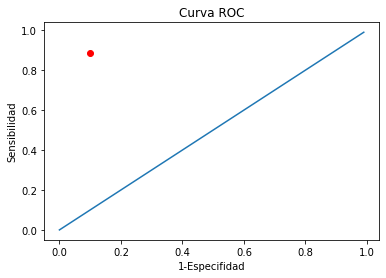

In [86]:
plt.plot(espc_1, 
         sens, 
         marker="o", 
         linestyle="--", 
         color="red")
x=[i*0.01 for i in range(100)]
y=[i*0.01 for i in range(100)]
plt.plot(x,y)
plt.xlabel("1-Especifidad")
plt.ylabel("Sensibilidad")
plt.title("Curva ROC")

## test

In [85]:
predict_test = clf.predict(x_test)
train = confusion_matrix(y_test, predict_test)
VN=train[1][1]
VP=train[0][0]
FP=train[0][1]
FN=train[1][0]
sens = VP/(VP+FN)
espc = VN/(VN+FP)
espc_1 = 1-espc
Acc= (VP+VN)/(VP+VN+FP+FN)

Text(0.5, 1.0, 'Curva ROC')

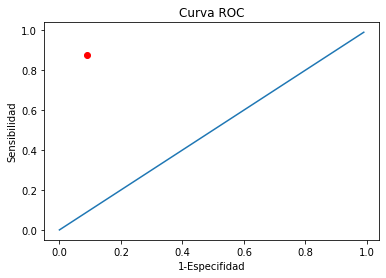

In [92]:
plt.plot(espc_1, 
         sens, 
         marker="o", 
         linestyle="--", 
         color="red")
x=[i*0.01 for i in range(100)]
y=[i*0.01 for i in range(100)]
plt.plot(x,y)
plt.xlabel("1-Especifidad")
plt.ylabel("Sensibilidad")
plt.title("Curva ROC")

In [93]:
espc_1

0.0890643852144346

In [94]:
sens

0.8778123022038092

In [96]:
from sklearn.metrics import precision_score
precisionSVC = precision_score(y_test, predict_test, average='macro')

In [108]:
print('precision')
print('random forest: ',precision_random_forest)
print('precision SVC: ',precisionSVC)

precision
random forest:  0.9492658132530121
precision SVC:  0.8943739584946873


In [86]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, predict_test)

0.8720169034278491

# export model

In [92]:
import joblib
joblib.dump(wqp_rf, "/home/david/technocolabs/EDA/random_forest.pkl")

['/home/david/technocolabs/EDA/random_forest.pkl']

In [93]:
x_train

,CreditScore,MIP,OCLTV,LTV,MonthsDelinquent,MonthsInRepayment,RepayRange,ltvRange,creditRange,MonthsDelinquentRange
127196,657,22,86,86,121,211,5,3,2,2
11644,577,25,87,87,0,92,2,3,1,1
50485,776,0,26,26,1,210,5,2,4,1
23757,709,0,70,70,0,140,3,3,3,1
3968,729,0,78,78,0,48,1,3,3,1
...,...,...,...,...,...,...,...,...,...,...
119879,677,0,77,77,79,197,5,3,2,2
103694,790,0,32,32,0,128,3,2,4,1
131932,646,1,80,80,50,210,5,3,1,2
146867,719,0,75,75,72,209,5,3,3,2


In [82]:
for i in range(len(df)):
    if (df.loc[i]['EverDelinquent']==0) and (df.loc[i]['MonthsDelinquent']!=0):
        print(i)

123
174
200
268
281
301
302
323
460
507
528
563
568
579
634
814
850
864
905
1007
1089
1139
1264
1268
1273
1311
1381
1383
1396
1400
1474
1529
1603
1631
1632
1633
1652
1654
1673
1688
1730
1764
1771
1779
1789
1802
1840
1883
1996
2029
2102
2114
2115
2185
2252
2405
2455
2484
2499
2568
2595
2601
2809
2838
2852
2910
2934
2972
2977
3001
3034
3047
3052
3071
3119
3146
3168
3188
3202
3212
3230
3246
3284
3362
3363
3378
3400
3408
3441
3478
3569
3576
3594
3620
3742
3750
3821
3822
3829
3861
3880
3931
3942
3980
3990
4026
4047
4103
4135
4248
4261
4352
4355
4368
4385
4409
4463
4479
4569
4639
4644
4667
4716
4722
4737
4757
4797
4805
4879
4958
4965
4996
5011
5116
5145
5155
5238
5244
5258
5265
5286
5306
5332
5370
5394
5417
5507
5607
5695
5794
5900
5901
5991
6058
6067
6121
6129
6223
6227
6229
6242
6243
6244
6273
6276
6318
6319
6344
6356
6436
6569
6573
6574
6583
6587
6659
6720
6731
6746
6797
6884
6901
6935
6975
6997
7043
7052
7114
7128
7158
7267
7353
7430
7544
7613
7708
7751
7759
7898
7945
7969
8024
8064
8094

34603
34618
34645
34654
34672
34689
34694
34723
34732
34784
34806
34810
34834
34865
34869
34875
34896
34899
34904
34913
34922
34923
34926
34927
34931
34950
34951
34959
34962
34966
34970
34971
34973
35017
35020
35027
35047
35056
35059
35065
35066
35084
35113
35132
35161
35177
35188
35194
35202
35210
35239
35241
35247
35252
35256
35259
35260
35266
35273
35281
35294
35309
35325
35330
35353
35365
35371
35405
35425
35426
35438
35450
35458
35474
35475
35476
35477
35480
35481
35486
35489
35492
35500
35549
35576
35594
35596
35597
35609
35613
35634
35635
35675
35688
35696
35711
35712
35735
35740
35811
35827
35847
35848
35854
35892
35895
35896
35897
35930
35932
35956
35978
35985
36058
36075
36083
36105
36121
36165
36168
36179
36229
36257
36260
36268
36286
36291
36295
36300
36330
36340
36353
36366
36367
36375
36376
36386
36397
36403
36406
36407
36448
36457
36463
36472
36481
36490
36495
36501
36503
36504
36515
36538
36539
36584
36599
36600
36601
36611
36636
36637
36703
36706
36716
36728
36742
3675

59736
59742
59746
59747
59750
59754
59755
59761
59765
59766
59788
59790
59805
59820
59823
59871
59879
59882
59894
59915
59916
59919
59928
59961
59972
59979
59988
59995
60008
60012
60028
60038
60045
60081
60083
60094
60102
60106
60112
60132
60143
60193
60198
60201
60205
60211
60222
60228
60256
60258
60266
60274
60277
60281
60290
60303
60305
60308
60309
60314
60315
60319
60322
60331
60333
60336
60341
60364
60369
60373
60374
60385
60409
60410
60425
60427
60428
60440
60443
60456
60494
60495
60498
60499
60502
60514
60516
60529
60539
60541
60546
60559
60599
60606
60623
60629
60631
60635
60637
60651
60656
60663
60682
60694
60703
60739
60755
60757
60763
60764
60776
60820
60851
60860
60866
60868
60875
60878
60883
60887
60902
60909
60914
60936
60939
60971
60975
60977
60984
60997
61016
61018
61030
61043
61045
61052
61077
61084
61090
61101
61111
61147
61148
61162
61170
61177
61178
61204
61221
61237
61263
61267
61288
61305
61320
61331
61338
61340
61342
61344
61347
61361
61362
61366
61384
61398
6140

73766
73769
73783
73795
73801
73823
73827
73840
73845
73861
73864
73870
73874
73890
73933
73959
73964
73985
73996
74000
74005
74014
74015
74024
74028
74033
74034
74035
74040
74041
74051
74055
74061
74076
74077
74119
74125
74134
74136
74156
74161
74163
74167
74172
74174
74187
74192
74193
74216
74234
74239
74262
74276
74279
74281
74289
74310
74325
74332
74335
74345
74362
74373
74382
74388
74393
74395
74397
74406
74409
74411
74460
74473
74476
74480
74486
74507
74510
74531
74545
74555
74561
74565
74567
74569
74605
74625
74636
74664
74671
74674
74675
74685
74689
74694
74698
74704
74707
74731
74736
74738
74743
74746
74783
74789
74803
74822
74824
74838
74848
74867
74871
74887
74888
74896
74901
74906
74908
74921
74931
74960
74963
74971
74985
74999
75048
75050
75058
75060
75062
75066
75088
75090
75105
75117
75128
75140
75145
75152
75177
75185
75190
75204
75215
75216
75226
75239
75247
75248
75264
75267
75292
75310
75317
75329
75338
75340
75351
75352
75357
75376
75401
75409
75414
75427
75434
7544

89595
89646
89660
89661
89681
89682
89685
89699
89702
89704
89711
89718
89719
89729
89742
89760
89770
89774
89787
89797
89802
89816
89820
89828
89833
89834
89851
89864
89866
89873
89885
89891
89923
89943
89944
89950
89961
89978
89982
89995
90006
90014
90016
90027
90028
90052
90060
90072
90073
90075
90081
90082
90086
90090
90094
90100
90109
90134
90139
90147
90158
90161
90166
90169
90175
90178
90184
90201
90210
90213
90215
90217
90229
90240
90255
90258
90259
90260
90264
90266
90271
90285
90290
90296
90297
90304
90309
90318
90331
90334
90335
90343
90349
90387
90393
90401
90410
90414
90423
90435
90436
90450
90454
90468
90471
90476
90483
90489
90515
90516
90517
90544
90546
90556
90565
90573
90581
90593
90594
90596
90624
90631
90634
90640
90654
90657
90663
90682
90691
90704
90726
90735
90745
90759
90760
90766
90781
90791
90798
90817
90823
90825
90831
90842
90846
90855
90862
90865
90866
90868
90872
90878
90881
90891
90892
90896
90899
90903
90904
90906
90918
90919
90933
90947
90951
90955
9095

...

124868
124877
124892
124928
124931
124933
124947
124960
124962
124967
124974
124976
124977
124980
124995
124997
125017
125043
125053
125080
125087
125103
125107
125110
125116
125118
125122
125125
125130
125154
125162
125165
125172
125173
125178
125186
125189
125191
125204
125206
125224
125241
125244
125256
125258
125262
125269
125288
125291
125332
125339
125352
125386
125418
125420
125444
125448
125480
125501
125510
125519
125520
125527
125529
125532
125539
125541
125554
125557
125567
125572
125576
125601
125608
125619
125626
125629
125632
125639
125645
125655
125660
125671
125681
125688
125701
125704
125705
125709
125721
125736
125738
125747
125749
125771
125780
125782
125783
125793
125817
125838
125852
125864
125867
125880
125918
125922
125923
125927
125936
125937
125957
125964
125982
125992
126008
126031
126032
126038
126050
126052
126053
126063
126067
126071
126074
126107
126122
126126
126154
126156
126163
126188
126193
126205
126211
126222
126224
126234
126238
126241
126256
126258

137746
137757
137759
137763
137769
137783
137785
137807
137813
137829
137834
137835
137858
137881
137890
137903
137914
137919
137922
137928
137946
137969
137985
137990
138002
138028
138042
138043
138047
138056
138070
138090
138094
138104
138108
138109
138122
138124
138130
138133
138144
138145
138151
138153
138155
138171
138181
138183
138202
138225
138260
138262
138264
138272
138277
138285
138295
138301
138325
138338
138345
138369
138385
138393
138394
138408
138412
138415
138419
138422
138428
138431
138440
138449
138452
138456
138461
138472
138475
138497
138500
138507
138520
138522
138525
138544
138547
138557
138567
138575
138590
138593
138613
138624
138625
138633
138659
138660
138679
138692
138695
138708
138709
138715
138723
138726
138728
138740
138746
138747
138752
138775
138776
138778
138789
138801
138808
138824
138832
138860
138866
138868
138869
138871
138904
138931
138951
138967
138981
138998
139006
139008
139026
139048
139051
139059
139063
139068
139075
139078
139089
139103
139111

150840
150845
150855
150874
150875
150879
150884
150885
150889
150890
150900
150905
150909
150928
150947
150951
150966
150967
150969
150974
150976
150981
150985
151000
151001
151009
151014
151018
151020
151021
151023
151024
151039
151052
151053
151056
151067
151076
151078
151084
151103
151124
151135
151136
151142
151144
151146
151149
151161
151174
151179
151183
151200
151213
151231
151232
151237
151247
151266
151270
151271
151291
151292
151314
151332
151334
151336
151342
151358
151372
151373
151380
151389
151393
151406
151408
151440
151445
151458
151471
151486
151487
151501
151507
151526
151529
151535
151541
151551
151558
151589
151595
151609
151625
151643
151646
151654
151679
151693
151705
151729
151732
151735
151736
151755
151762
151774
151781
151784
151789
151792
151822
151829
151832
151848
151876
151878
151884
151887
151893
151894
151905
151911
151939
151953
151971
151977
151985
152001
152008
152011
152013
152014
152019
152034
152047
152048
152055
152065
152067
152082
152100
152109

164197
164200
164201
164206
164211
164220
164249
164251
164263
164272
164284
164291
164297
164311
164312
164335
164340
164347
164352
164367
164371
164385
164397
164405
164422
164431
164442
164447
164451
164453
164455
164478
164482
164488
164493
164495
164503
164510
164514
164520
164523
164531
164532
164537
164545
164557
164571
164581
164583
164608
164654
164697
164711
164734
164748
164751
164759
164777
164798
164807
164808
164810
164812
164814
164834
164837
164859
164880
164888
164892
164895
164906
164926
164932
164935
164962
164967
164969
164971
164982
164999
165009
165011
165023
165034
165040
165041
165044
165050
165070
165082
165089
165102
165105
165113
165118
165121
165128
165129
165153
165167
165187
165207
165222
165241
165258
165273
165280
165295
165303
165304
165305
165310
165318
165321
165334
165340
165358
165365
165370
165377
165389
165390
165393
165397
165401
165441
165442
165446
165447
165448
165455
165499
165505
165514
165533
165552
165554
165559
165562
165578
165614
165617

175841
175852
175888
175899
175924
175925
175930
175937
175950
175952
175956
175958
175961
175967
175980
175986
175988
175994
176011
176015
176025
176074
176099
176141
176144
176150
176157
176171
176182
176186
176197
176199
176206
176213
176233
176238
176243
176251
176256
176258
176266
176268
176269
176270
176272
176276
176300
176314
176346
176351
176352
176358
176360
176373
176382
176384
176387
176388
176390
176393
176394
176395
176400
176411
176413
176421
176427
176430
176432
176446
176456
176466
176479
176481
176494
176500
176507
176520
176521
176524
176527
176534
176537
176544
176546
176552
176554
176564
176573
176577
176581
176585
176586
176589
176598
176606
176611
176629
176631
176646
176664


In [83]:
df.loc[123]

CreditScore              654
MIP                       30
OCLTV                     95
LTV                       95
EverDelinquent             0
MonthsDelinquent           9
MonthsInRepayment         47
RepayRange                 1
ltvRange                   3
creditRange                2
MonthsDelinquentRange      1
Name: 123, dtype: int64